# 05 · Feature spaces, PCA and nonlinear projections

Explore a high-dimensional numerical space from several angles: variance spectrum, group-aware PCA scores, loading structure, biplot and exploratory nonlinear projection.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_pca, analyze_tsne
frame,dataset=load_tabular_demo(); features=load_feature_demo('representation_a')
pca=analyze_pca(features,n_components=6,scaling='standard',random_state=42)
tsne=analyze_tsne(features,n_components=2,scaling='standard',perplexity=25,random_state=42,max_iter=500)

## Scree and cumulative variance

findfont: Failed to find font weight semibold, now using 700.


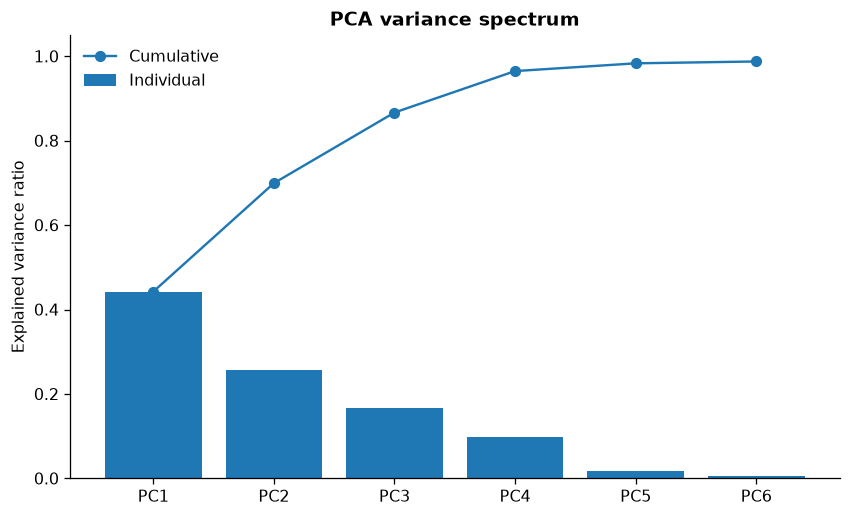

In [2]:
v=pca.variance; fig,ax=plt.subplots(figsize=(7.5,4.6)); ax.bar(v.component,v.explained_variance_ratio,label='Individual'); ax.plot(v.component,v.cumulative_explained_variance_ratio,marker='o',label='Cumulative'); ax.set_ylim(0,1.05); ax.set_ylabel('Explained variance ratio'); ax.set_title('PCA variance spectrum'); ax.legend(); finish(fig); plt.show()

## PCA scores by group and phenotype

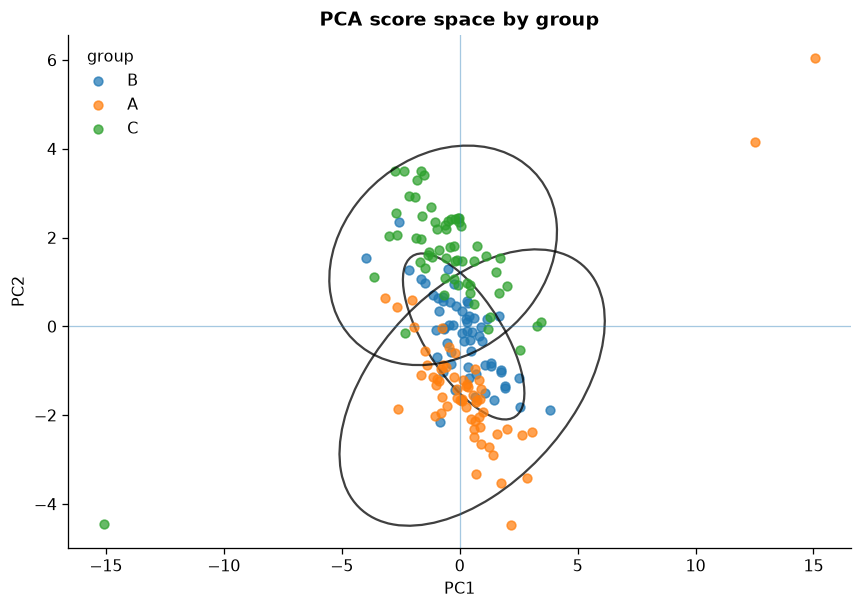

In [3]:
score_plot(pca.scores,frame,x='PC1',y='PC2',group='group',title='PCA score space by group',ellipses=True); plt.show()

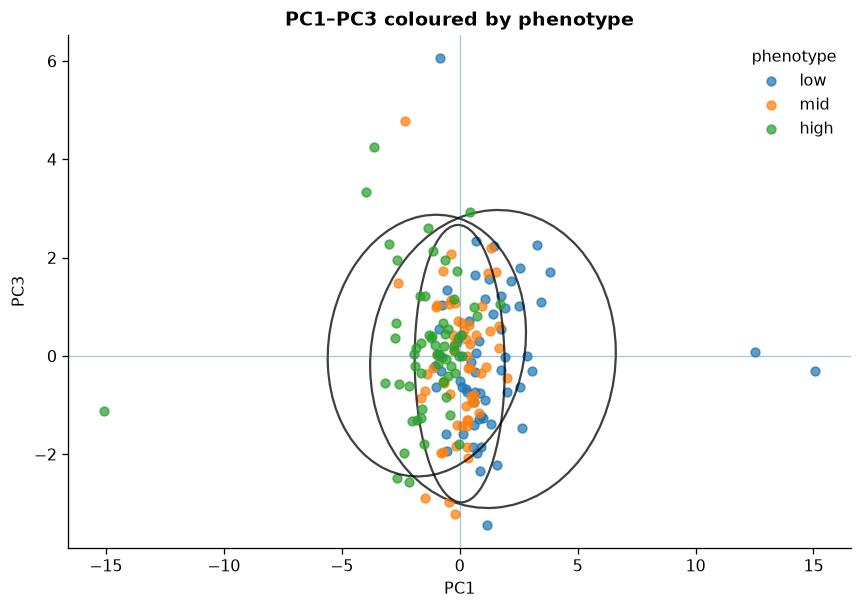

In [4]:
score_plot(pca.scores,frame,x='PC1',y='PC3',group='phenotype',title='PC1–PC3 coloured by phenotype',ellipses=True); plt.show()

## Loadings and biplot

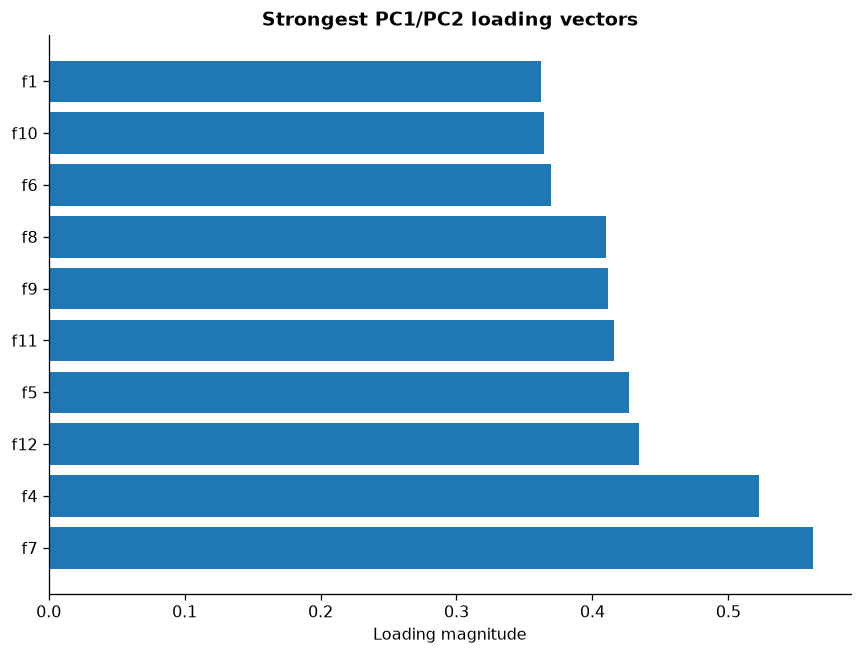

In [5]:
load=pca.loadings.copy(); load['magnitude']=np.sqrt(load.PC1**2+load.PC2**2); top=load.nlargest(10,'magnitude'); bar_metric(top.sort_values('magnitude'),label='feature',value='magnitude',title='Strongest PC1/PC2 loading vectors',ylabel='Loading magnitude'); plt.show()

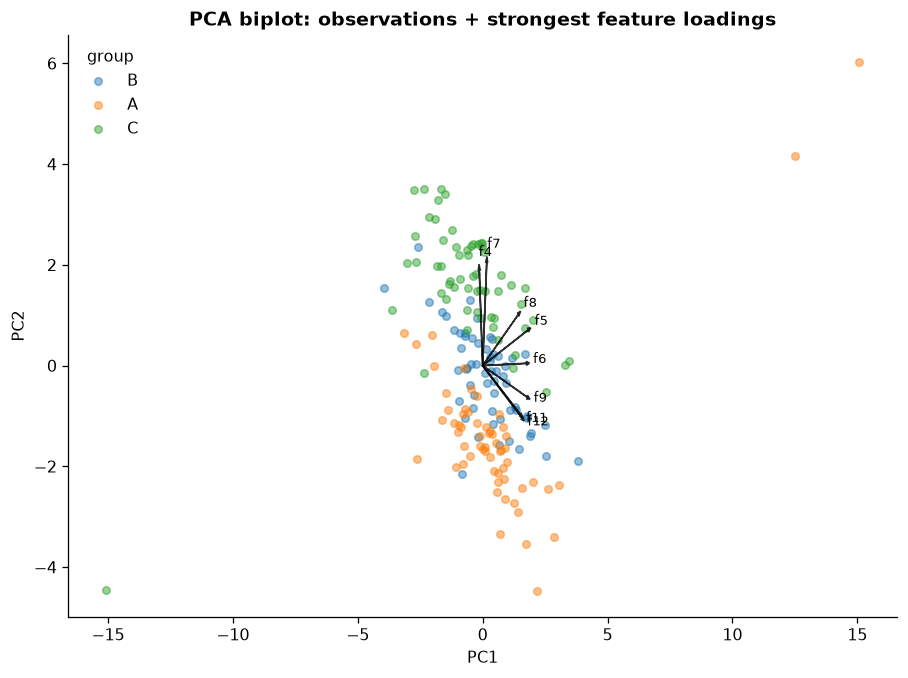

In [6]:
biplot(pca.scores,pca.loadings,frame,group='group',top_n=8,title='PCA biplot: observations + strongest feature loadings'); plt.show()

## Exploratory t-SNE
Ruddy explicitly marks t-SNE coordinates as non-inferential.

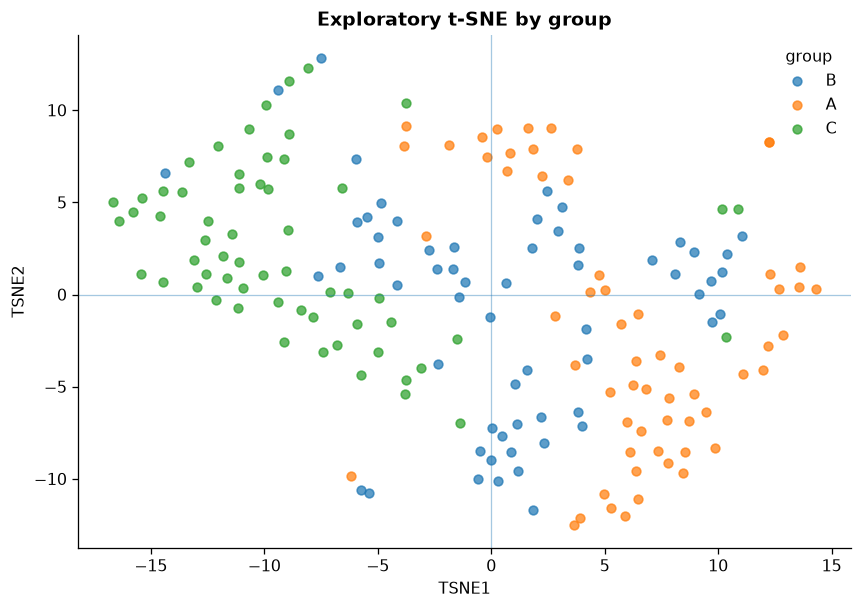

inferential_allowed = False


In [7]:
coords=tsne.coordinates.rename(columns={'component_1':'TSNE1','component_2':'TSNE2'}); score_plot(coords,frame,x='TSNE1',y='TSNE2',group='group',title='Exploratory t-SNE by group'); plt.show(); print('inferential_allowed =',tsne.inferential_allowed)

## Interactive PCA explorer

In [8]:
import plotly.express as px
interactive=pca.scores.merge(frame[['id','group','source','phenotype','activity']],left_on='observation_id',right_on='id')
fig=px.scatter(interactive,x='PC1',y='PC2',color='group',symbol='source',hover_data=['observation_id','phenotype','activity'],title='Interactive PCA score explorer')
fig